In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## DATA EXPLORATION

In [3]:
df=pd.read_csv(r"C:\Users\Jayishnu Kumar Jha\Downloads\Indian-Resturants.csv")
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [4]:
print(df.shape)         

(211944, 26)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

### CONCLUSION

#### Dataset has over 211k entries . Cuisines , zipcode , timings and opentable_support have missing values.

## AVERAGE RATING BY PRICE RANGE

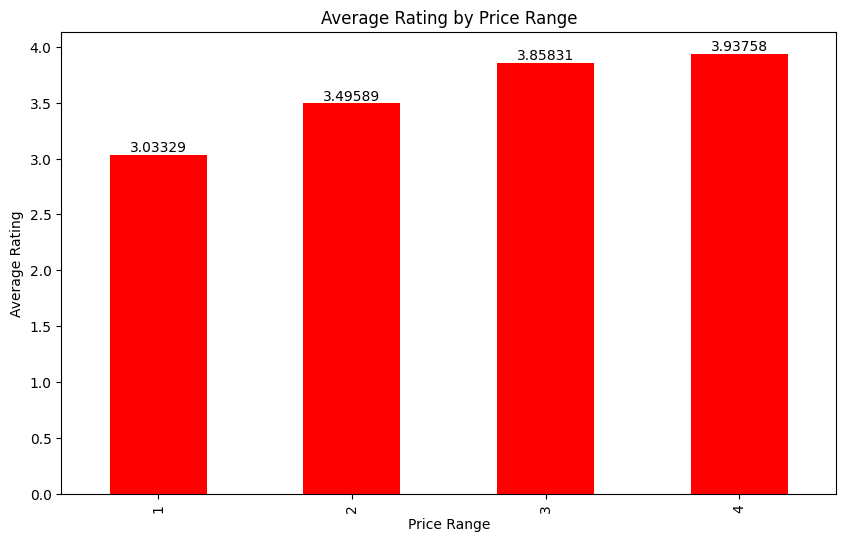

In [7]:
rating_by_price = df.groupby('price_range')['aggregate_rating'].mean()
plt.figure(figsize=(10,6))
ax=rating_by_price.plot(kind='bar',color='r')
ax.bar_label(ax.containers[0])
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()

### CONCLUSION

#### Higher priced restaurants generally recieve higher ratings

## TOP 10 CITIES BY NUMBER OF RESTAURANTS

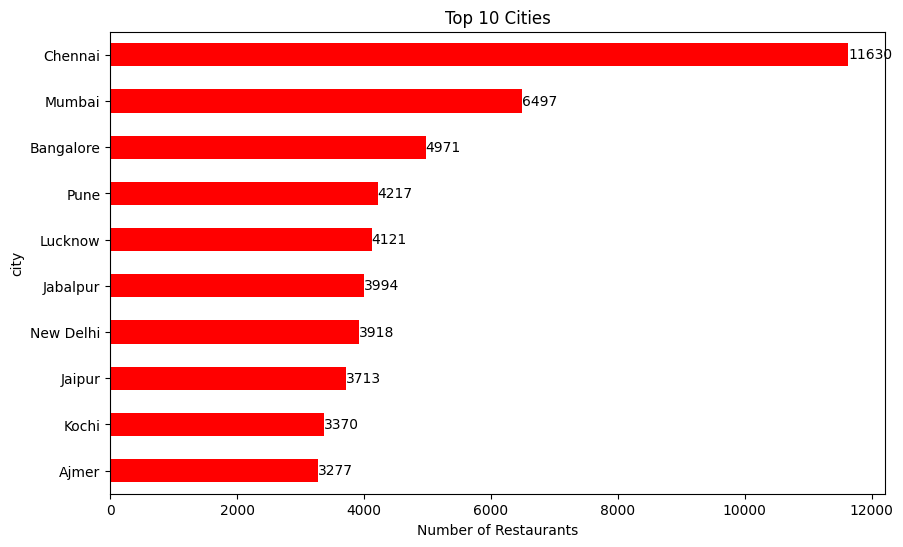

In [8]:
top_cities = df["city"].value_counts().head(10)
plt.figure(figsize=(10,6))
ax=top_cities.sort_values().plot(kind='barh',color='r')
ax.bar_label(ax.containers[0])
plt.title("Top 10 Cities")
plt.xlabel("Number of Restaurants")
plt.show()

### CONCLUSION

#### Chennai has the maximum number of restaurants amongst the top 10 cities 

## TOP 10 CUISINES

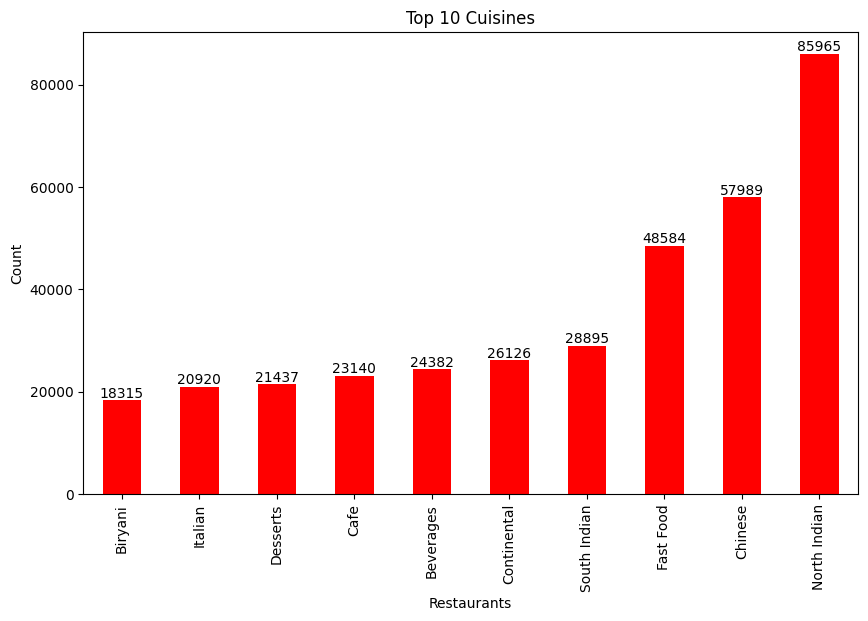

In [21]:
cuisines = df["cuisines"].dropna().str.split(",")
cuisine_list = cuisines.explode().str.strip()
top_cuisine = cuisine_list.value_counts().head(10)
plt.figure(figsize=(10,6))
ax=top_cuisine.sort_values().plot(kind='bar',color='r')
ax.bar_label(ax.containers[0])
plt.title("Top 10 Cuisines")
plt.xlabel("Restaurants")
plt.ylabel("Count")
plt.show()

### CONCLUSION

#### North indian , chinese  and fast foods are the most likeable cuisines 

## AVERAGE RATING BY TOP 10 CITIES

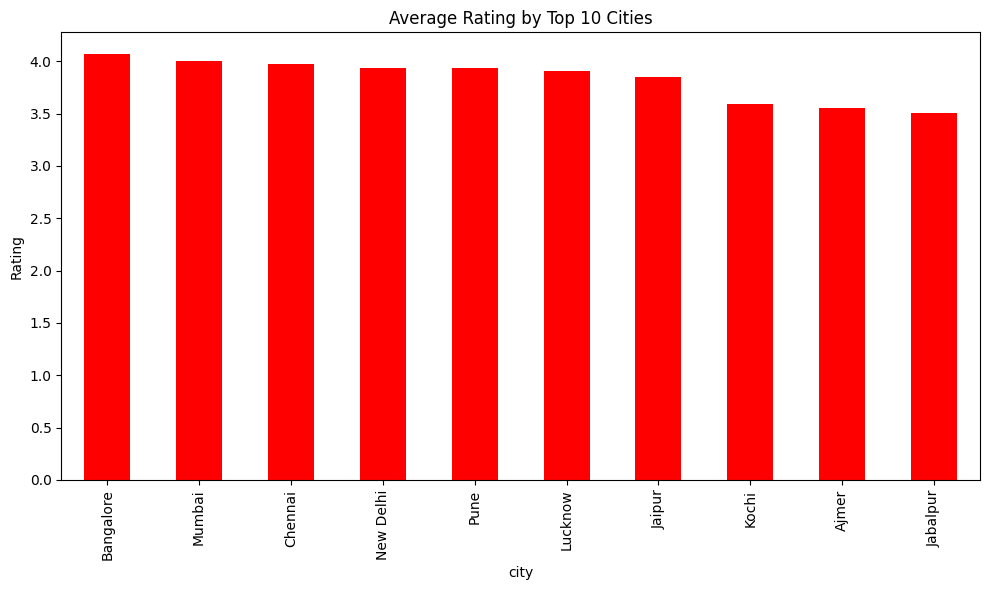

In [10]:
top_cities = df['city'].value_counts().head(10).index
avg_rating_city = df[df['city'].isin(top_cities)].groupby('city')['aggregate_rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
avg_rating_city.plot(kind='bar',color='r')
plt.title("Average Rating by Top 10 Cities")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

### CONCLUSION

#### Bangalore and Mumbai have the highest average restaurant ratings among top cities.

## TOP 10 MOST POPULAR RESTAURANTS

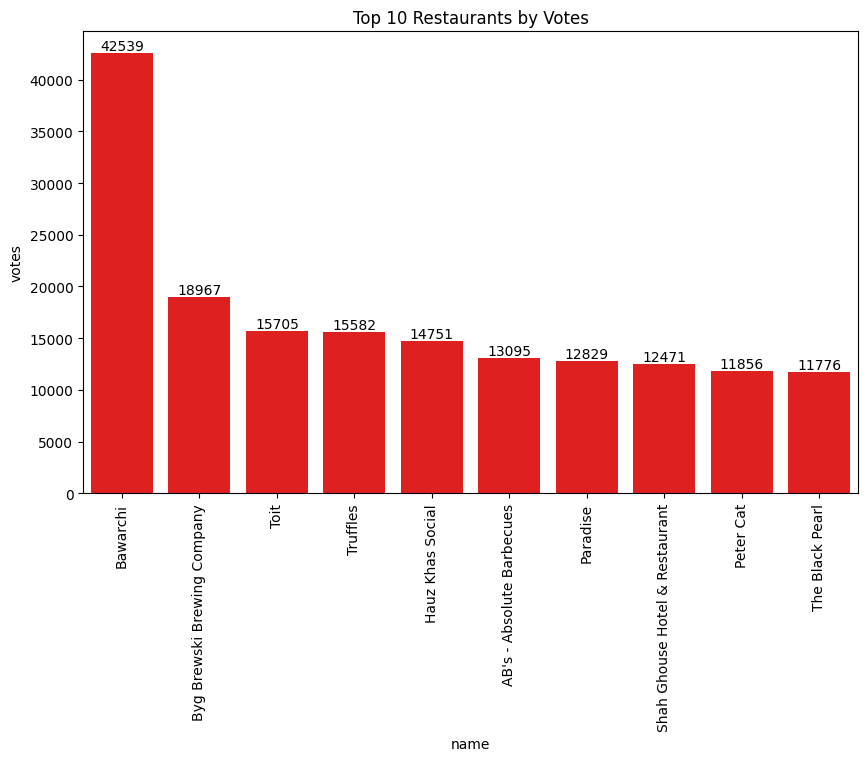

In [11]:
top_votes = (df.sort_values("votes",ascending=False).drop_duplicates("name").head(10))
plt.figure(figsize=(10,6))
ax=sns.barplot(data=top_votes,x="name",y="votes",color="red")
ax.bar_label(ax.containers[0])
plt.title("Top 10 Restaurants by Votes")
plt.xticks(rotation=90)
plt.show()

### CONCLUSION

#### Bawarchi has got the most number of votes

## TOP LOCALITIES

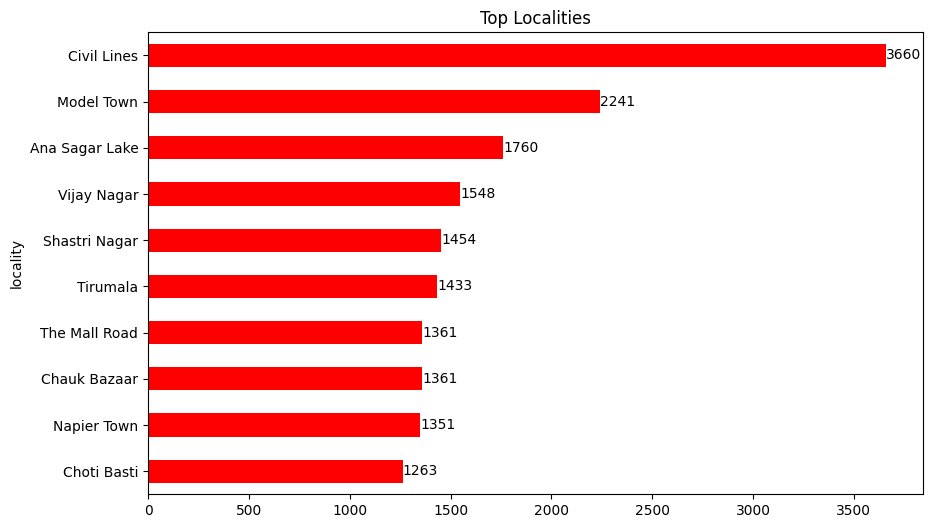

In [12]:
top_locality = df["locality"].value_counts().head(10)
plt.figure(figsize=(10,6))
ax=top_locality.sort_values().plot(kind='barh',color="r")
ax.bar_label(ax.containers[0])
plt.title("Top Localities")
plt.show()

### CONCLUSION

#### Civil Lines is the most common locality

## MOST EXPENSIVE RESTAURANTS 

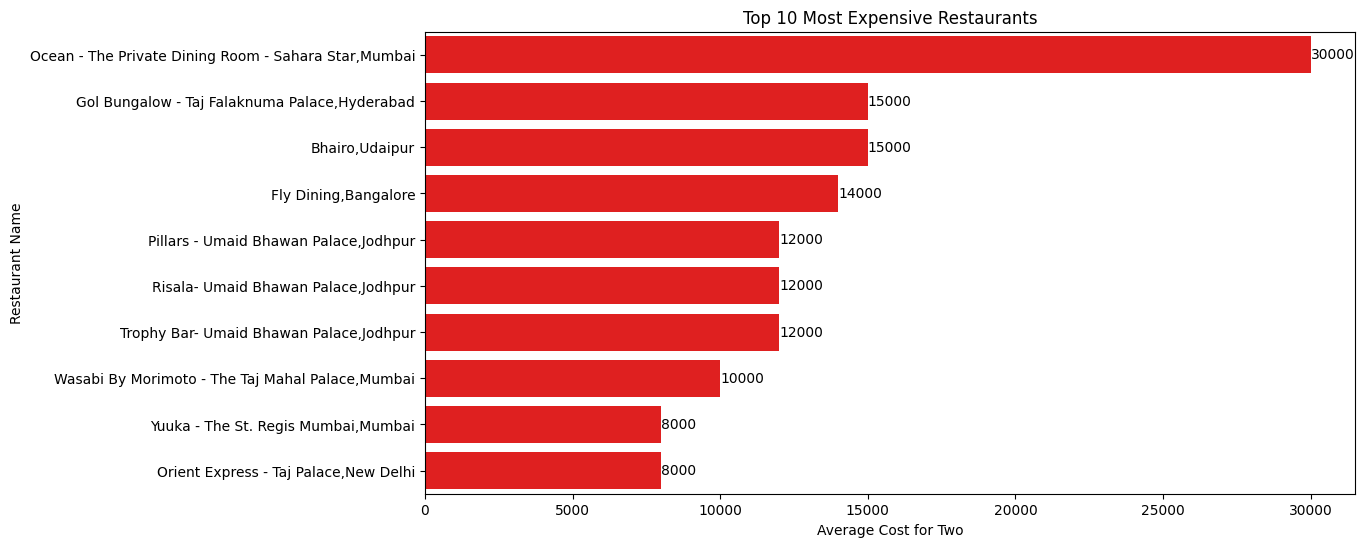

In [13]:
expensive=df[["name","city","average_cost_for_two"]].sort_values("average_cost_for_two",ascending=False).drop_duplicates(["name","city"]).head(10)
expensive["restaurant_city"]=expensive["name"]+","+expensive["city"]
plt.figure(figsize=(12,6))
ax=sns.barplot(y="restaurant_city",x="average_cost_for_two",data=expensive,color="r")
ax.bar_label(ax.containers[0])
plt.xlabel("Average Cost for Two")
plt.ylabel("Restaurant Name")
plt.title("Top 10 Most Expensive Restaurants")
plt.show()

### CONCLUSION

Ocean-The private dining room from Mumbai is the most expensive restaurant

## RESTAURANTS WITH MAXIMUM PHOTOS

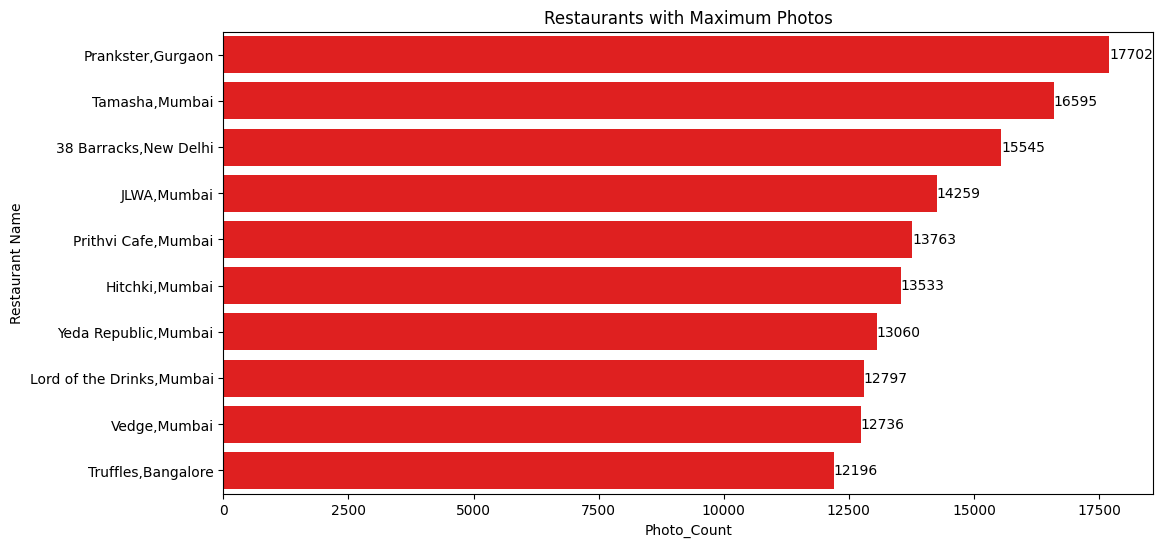

In [14]:
Photo_count=df.sort_values("photo_count",ascending=False)[["name","city","photo_count"]].drop_duplicates(["name","city"]).head(10)
Photo_count["restaurant_City"]=Photo_count["name"]+","+Photo_count["city"]
plt.figure(figsize=(12,6))
ax=sns.barplot(y="restaurant_City",x="photo_count",data=Photo_count,color="r")
ax.bar_label(ax.containers[0])
plt.xlabel("Photo_Count")
plt.ylabel("Restaurant Name")
plt.title("Restaurants with Maximum Photos")
plt.show()

### CONCLUSION

Prankster , Tamasha and 38 Barracks are the Restaurants having the most number of photos which were clicked by customers